In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import h5py
import os
from pathlib import Path

In [3]:
mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\100Mbps\water\ethernet_packets_1000_50cm.mat'
# mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\10Mbps\ethernet_packets_2501_5000.mat'
# mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\10Mbps\ethernet_packets_5001_7500.mat'
# mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\10Mbps\ethernet_packets_10001_12500.mat'


In [4]:
with h5py.File(mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

print(f"Sample Rate: {sample_rate} Hz")
print(f"Trigger Level: {trigger_level} V")
print(f"Record Length: {record_length} samples")
print(f"Number of Frames: {num_frames}")

Sample Rate: 1250000000.0 Hz
Trigger Level: 1.5 V
Record Length: 250000.0 samples
Number of Frames: 1000.0


In [5]:
len(reference_packet)

1000

In [6]:
for points in reference_packet[1]:
    print(points)

-0.023984375000000002
0.0036718750000000002
-0.002578125
-0.022734375
-0.039218750000000004
-0.0059375
-0.00109375
-0.025781250000000002
-0.016875
-0.00875
0.009375
0.041796875000000004
-0.00421875
0.03890625
0.05609375
0.0815625
0.115859375
0.166484375
0.194765625
0.24578125
0.247890625
0.287578125
0.312421875
0.2765625
0.254453125
0.27046875
0.267890625
0.28046875
0.2540625
0.2728125
0.288203125
0.274453125
0.243125
0.253828125
0.238515625
0.1909375
0.17578125
0.138125
0.1078125
0.08625000000000001
0.039375
0.086171875
0.07062500000000001
0.06015625
0.038671875
0.07046875
0.06171875
0.04859375
0.03296875
0.0346875
0.020234375
-0.0003125
-0.032421875
-0.01546875
-0.04671875
-0.066484375
-0.12859375
-0.16484375
-0.181953125
-0.239375
-0.299609375
-0.26609375
-0.246796875
-0.25203125
-0.25078125
-0.194609375
-0.145
-0.110078125
-0.0921875
-0.0209375
0.0121875
0.010234375
0.010546875
0.047109375
0.075
0.084375
0.071484375
0.174140625
0.20945312500000002
0.242265625
0.241640625
0.25898437

### Extract Signal Region 
- Extract Signal Region and while keeping the packet lengths uniform

In [7]:
def extract_signal_region(signal, threshold=0.1):
    """Trims the quiet parts of the signal before and after the packet."""
    active = np.abs(signal) > threshold
    indices = np.where(active)[0]
    if indices.size == 0:
        return np.array([])
    return signal[indices[0] : indices[-1] + 1]

[ 0.06420898  0.08312988  0.0345459  -0.0423584  -0.07226562 -0.02526855
  0.04980469  0.08935547  0.09033203  0.04064941]


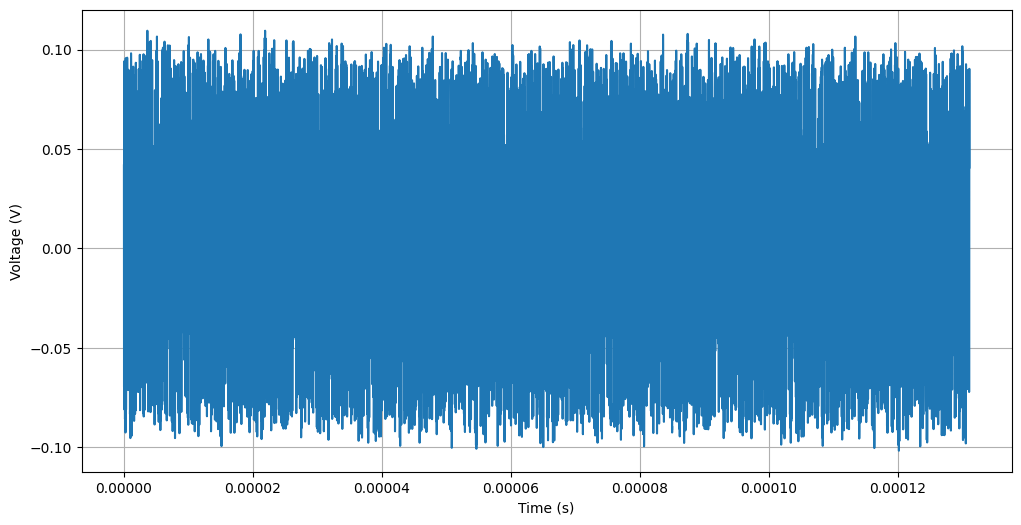

[ 0.04187012  0.04333496  0.0020752  -0.03405762 -0.0826416  -0.08654785
 -0.08728027 -0.03747559  0.04309082  0.08837891]


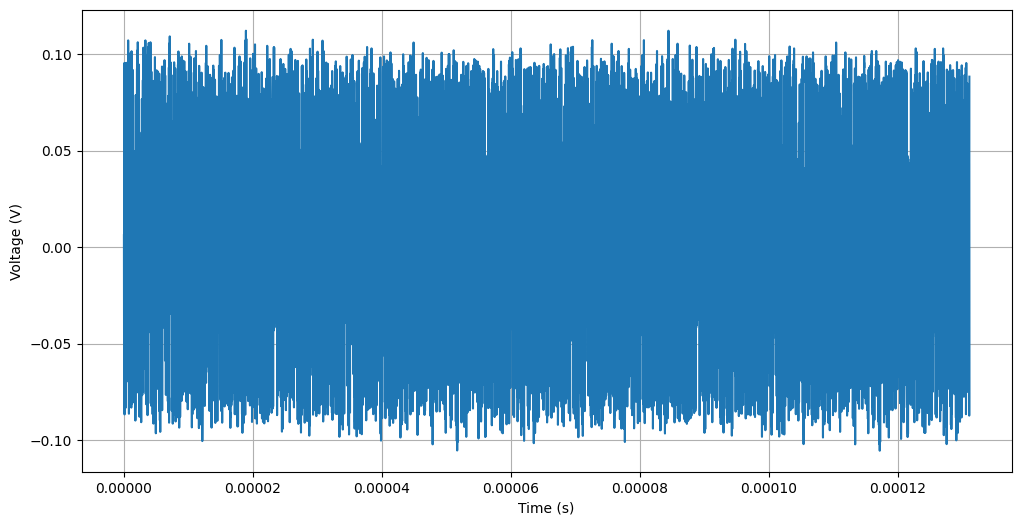

[-0.03393555 -0.07434082 -0.08862305 -0.06091309  0.02124023  0.07507324
  0.04992676  0.00134277 -0.0390625  -0.05517578]


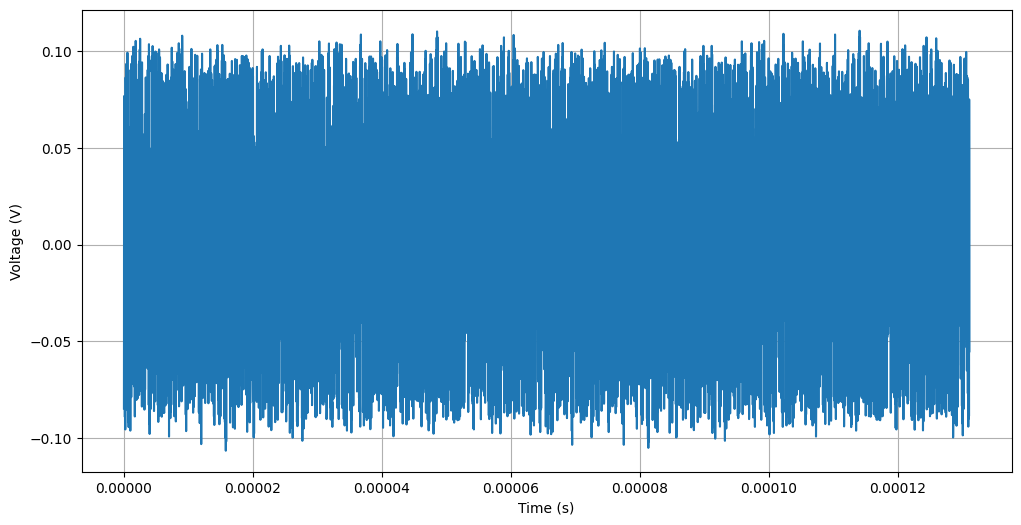

[ 0.09338379  0.06091309  0.02294922 -0.03259277 -0.08239746 -0.08483887
 -0.08520508 -0.03552246  0.00183105  0.01245117]


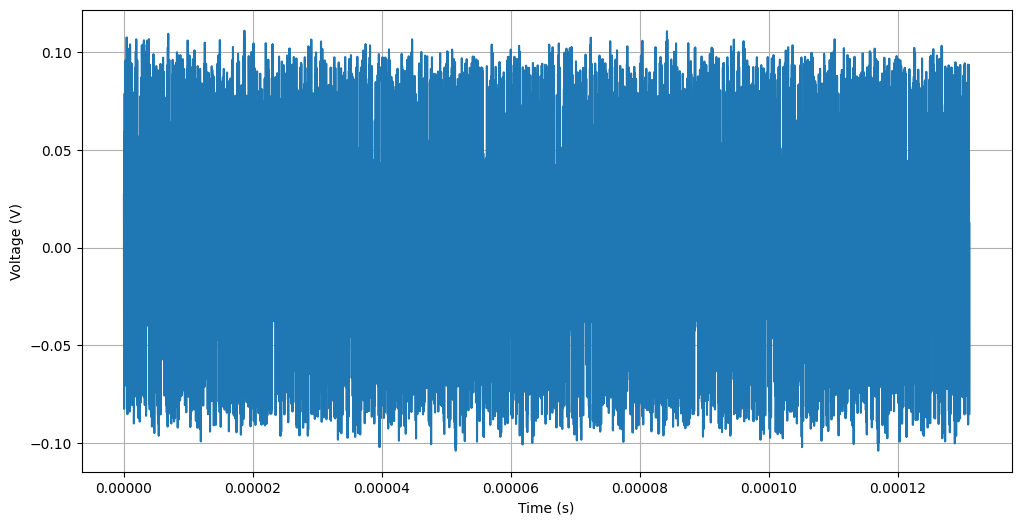

[ 0.08666992  0.0949707   0.07629395  0.02038574 -0.01464844 -0.04968262
  0.01806641  0.06152344  0.02636719  0.02453613]


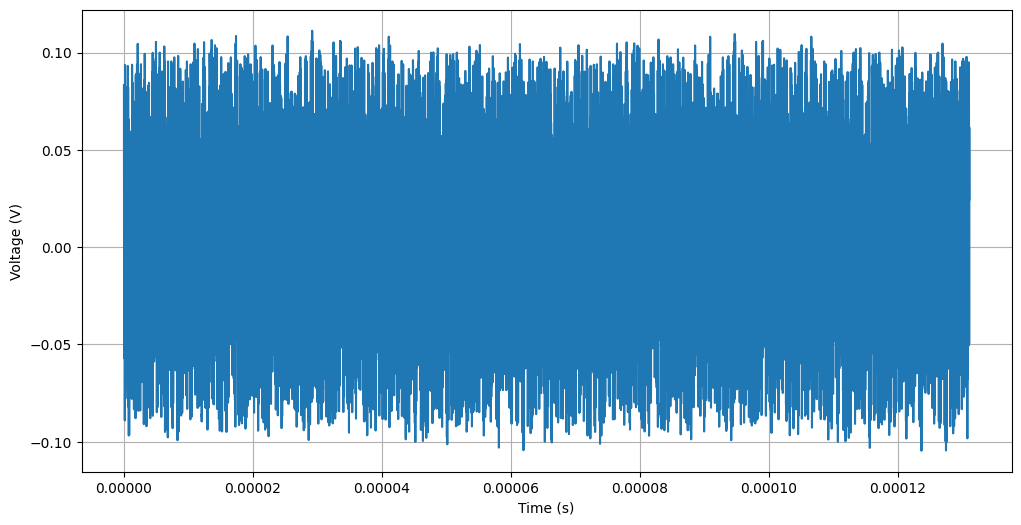

[-0.04016113 -0.01220703  0.01037598  0.07177734  0.0826416   0.01623535
 -0.0567627  -0.06445312 -0.01586914  0.01477051]


KeyboardInterrupt: 

In [8]:
time_axis = np.arange(record_length) / sample_rate
for packet in reference_packet[-10:]:
    print(f"{packet[-10:]}")
    plt.figure(figsize=(12,6))
    plt.plot(time_axis, packet, label='Packet')  # Plot each packet
    # plt.title(f'Reference Ethernet Packet')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.show()

In [ ]:
samples_per_bit = (sample_rate / 10e6)  # 10Mbps
samples_per_bit

np.float64(12.5)

In [ ]:
ideal_packet_length = (sample_rate / 10e6) *(8+148+4)*8
ideal_packet_length

np.float64(16000.0)

In [ ]:
for packet in reference_packet[:10]:
    trimmed_packet = extract_signal_region(packet)
    print(f"Trimmed packet length: {len(trimmed_packet)} samples")

Trimmed packet length: 16378 samples
Trimmed packet length: 16364 samples
Trimmed packet length: 16383 samples
Trimmed packet length: 16379 samples
Trimmed packet length: 16366 samples
Trimmed packet length: 16382 samples
Trimmed packet length: 16354 samples
Trimmed packet length: 16378 samples
Trimmed packet length: 16382 samples
Trimmed packet length: 16382 samples


In [ ]:
count = 0
max_packet_length = 0
min_packet_length = float('inf')  # Start with max possible length
for packet in reference_packet:
    trimmed_packet = extract_signal_region(packet)
    if len(trimmed_packet) < ideal_packet_length:
        count += 1
        continue
    if len(trimmed_packet) > max_packet_length:
        max_packet_length = len(trimmed_packet)
    if len(trimmed_packet) < min_packet_length:
        min_packet_length = len(trimmed_packet)
count

0

In [ ]:
print(f"Max packet length: {max_packet_length} samples")
print(f"Min packet length: {min_packet_length} samples")
print(f"Number of packets shorter than ideal length: {count} out of {len(reference_packet)}")

Max packet length: 16384 samples
Min packet length: 16333 samples
Number of packets shorter than ideal length: 0 out of 1000


In [ ]:
def length_standardization(extracted_signal, target_length=160000):
    """
    Standardizes signal to target_length. 
    Validates that the input is within a +/- 500 sample tolerance before padding.
    """
    current_len = len(extracted_signal)
    tolerance = 500 

    # 1. Check if it's too long
    if current_len > (target_length + tolerance):
        raise ValueError(f"Signal ({current_len}) exceeds target + tolerance.")

    # 2. Check if it's too short
    if current_len < (target_length - tolerance):
        raise ValueError(f"Signal ({current_len}) is below target - tolerance.")

    # 3. Standardize
    if current_len > target_length:
        # If within tolerance but slightly over, clip it
        return extracted_signal[:target_length]
    else:
        # If within tolerance but slightly under, pad it
        pad_size = target_length - current_len
        return np.pad(extracted_signal, (0, pad_size), mode='constant')

In [ ]:
for packet in reference_packet:
    trimmed_packet = extract_signal_region(packet)
    if len(trimmed_packet) < ideal_packet_length:
        continue  # Skip packets that are too short
    try:
        prepared_packet = length_standardization(trimmed_packet, target_length=160000)
        print(f"Prepared packet length: {len(prepared_packet)} samples")
    except ValueError as e:
        print(e)
    

Signal (16378) is below target - tolerance.
Signal (16364) is below target - tolerance.
Signal (16383) is below target - tolerance.
Signal (16379) is below target - tolerance.
Signal (16366) is below target - tolerance.
Signal (16382) is below target - tolerance.
Signal (16354) is below target - tolerance.
Signal (16378) is below target - tolerance.
Signal (16382) is below target - tolerance.
Signal (16382) is below target - tolerance.
Signal (16366) is below target - tolerance.
Signal (16378) is below target - tolerance.
Signal (16379) is below target - tolerance.
Signal (16380) is below target - tolerance.
Signal (16349) is below target - tolerance.
Signal (16384) is below target - tolerance.
Signal (16382) is below target - tolerance.
Signal (16377) is below target - tolerance.
Signal (16383) is below target - tolerance.
Signal (16365) is below target - tolerance.
Signal (16377) is below target - tolerance.
Signal (16377) is below target - tolerance.
Signal (16382) is below target -

In [ ]:
# def replace_data_with_h5(mat_file_path, count = None):
#     path = Path(mat_file_path)
#     parts = list(path.parts)

#     # Replace 'data' with 'h5_data'
#     parts = ["h5_data" if p == "data" else p for p in parts[:-1]]
#     if count is None:
#         return str(Path(*parts, path.stem + ".h5"))
#     return str(Path(*parts, path.stem + f"_{count}.h5"))

In [ ]:
output_tmp = replace_data_with_h5(mat_file)  # Start with count=0 for temporary file
# Extract directory
dir_path = os.path.dirname(output_tmp)

# Create directory if it doesn't exist
os.makedirs(dir_path, exist_ok=True)

# Abort if file already exists
if os.path.exists(output_tmp):
    raise FileExistsError(f"File already exists: {output_tmp}")
target_length = 160250

count = 0

with h5py.File(output_tmp, "w") as f:
    dset = f.create_dataset(
        "signals",
        shape=(0, target_length),
        maxshape=(None, target_length),
        dtype=np.float32,
        chunks=True,
        compression="gzip",
        compression_opts=9
    )

    for packet in reference_packet:
        trimmed_packet = extract_signal_region(packet)

        if len(trimmed_packet) < ideal_packet_length:
            continue

        try:
            prepared_packet = prepare_for_classification(
                trimmed_packet,
                target_length=target_length
            )

            prepared_packet = np.asarray(prepared_packet, dtype=np.float32)

            dset.resize(count + 1, axis=0)
            dset[count] = prepared_packet

            count += 1
            print(f"Stored packet {count}")

        except ValueError as e:
            print(e)

    # store metadata inside file (VERY important)
    f.attrs["num_signals"] = count
    f.attrs["target_length"] = target_length



# rename AFTER writing
final_name = replace_data_with_h5(mat_file, count)
os.rename(output_tmp, final_name)

print("Saved as:", final_name)

NameError: name 'replace_data_with_h5' is not defined

In [ ]:
def extract_time_domain_features(signal):
    """Extract time-domain statistical features"""
    features = {}
    
    # Basic statistical moments
    features['std'] = np.std(signal)
    features['skewness'] = skew(signal)
    features['rms'] = np.sqrt(np.mean(signal**2))
    features['mean'] = np.mean(signal)
    features['kurtosis'] = kurtosis(signal)
    features['peak'] = np.max(np.abs(signal))
    
    # Shape factors
    features['shape_factor'] = features['rms'] / np.mean(np.abs(signal)) if np.mean(np.abs(signal)) != 0 else 0
    features['impulse_factor'] = features['peak'] / np.mean(np.abs(signal)) if np.mean(np.abs(signal)) != 0 else 0
    features['crest_factor'] = features['peak'] / features['rms'] if features['rms'] != 0 else 0
    features['clearance_factor'] = features['peak'] / (np.mean(np.sqrt(np.abs(signal)))**2) if np.mean(np.sqrt(np.abs(signal))) != 0 else 0
    
    return features

In [ ]:
def extract_frequency_domain_features(signal, fs):
    """Extract frequency-domain features"""
    # Compute FFT
    fft_signal = fft(signal)
    freqs = fftfreq(len(signal), 1/fs)
    
    # Get positive frequencies only
    positive_freq_idx = freqs > 0
    fft_positive = fft_signal[positive_freq_idx]
    freqs_positive = freqs[positive_freq_idx]
    
    # Find top 10 harmonic components
    magnitudes = np.abs(fft_positive)
    top_indices = np.argsort(magnitudes)[-10:]
    
    features = {}
    for i, idx in enumerate(top_indices):
        features[f'freq_mag_{i}'] = magnitudes[idx]
        features[f'freq_val_{i}'] = freqs_positive[idx]
    
    return features